## Loading dataset

thanks to Pumi!! Here will use his method in claening unvalid/empty data!

In [90]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
df = pd.read_csv("./music_genre_cleaned.csv")

## Data Distrubution
Should we use Logitic Regression or Linear Regression to the popularity?

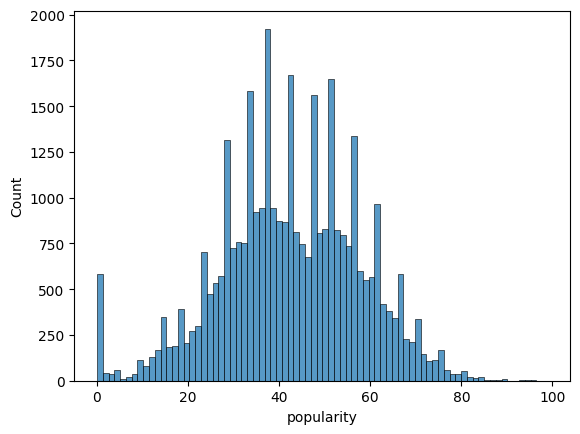

In [92]:
# using seaborn to plot the distribution of the popularity
sns.histplot(df['popularity'])
plt.show()

# -> this is a single peck distrubtion, and we will do: 
# linear regression: predict this directly
# Top 25%: predict which will be in the top 25%

In [93]:
# it has some zero, lets check them
df.loc[df['popularity'] == 0]

,Unnamed: 0,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
483,483,22302.0,Underworld,Threat Of Rain,0.0,0.178000,0.702,890680.0,0.5630,0.890000,C,0.1510,-15.157,Major,0.0500,130.003,4-Apr,0.5810,Electronic
693,693,43800.0,Wuki,IGD,0.0,0.000019,0.534,168000.0,0.9940,0.922000,C#,0.3590,-1.947,Major,0.0460,130.034,4-Apr,0.0295,Electronic
2172,2172,39194.0,UMEK,Hablando - Umek Remix,0.0,0.001040,0.744,360000.0,0.8600,0.687000,E,0.3150,-7.026,Minor,0.0498,129.910,4-Apr,0.4580,Electronic
2204,2204,68085.0,Timo Maas,Heaven Is Hell,0.0,0.088800,0.800,418100.0,0.8260,0.891000,C,0.1490,-8.692,Major,0.0477,119.984,4-Apr,0.3420,Electronic
2230,2230,79345.0,graves,Intro,0.0,0.068600,0.541,100339.0,0.8030,0.025500,F,0.5810,-10.165,Major,0.2910,174.069,4-Apr,0.2940,Electronic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32564,32564,55940.0,Giuseppe Verdi,"Falstaff, Act I Pt. 1: Sei polli, sei scellini...",0.0,0.956000,0.343,385093.0,0.1200,0.000055,D,0.7240,-24.190,Major,0.0688,86.550,4-Apr,0.2080,Classical
32567,32567,29416.0,empty_field,"Piano Sonata No. 30 in E Major, Op. 109: IIIc....",0.0,0.991000,0.391,85890.0,0.0362,0.881000,E,0.0955,-32.662,Major,0.0453,71.875,4-Apr,0.4130,Classical
32577,32577,67714.0,Ludwig van Beethoven,"Fidelio, Op. 72, Act I: Hat man nicht auch Gol...",0.0,0.957000,0.434,151187.0,0.0872,0.000055,A#,0.7820,-26.091,Major,0.0515,78.862,4-Apr,0.4120,Classical
32596,32596,39090.0,empty_field,"La clemenza di Tito, K. 621, Act II: Torna di ...",0.0,0.969000,0.298,137027.0,0.0526,0.000000,G,0.5510,-27.488,Major,0.0557,85.018,3-Apr,0.2170,Classical


In [94]:
# remove the zeros
df = df[df['popularity'] != 0]

## clean the features.
The Linear Regression Request the features:
#### Linearity
The relationship between independent variables and the dependent variable is linear. A change in the independent variables should lead to a direct proportional change in the dependent variable.
#### No Multicollinearity
Make sure independent variables are NOT highly correlated with each other, otherwise the model becomes unstable. We will make a corr heapmap show this.

**Drop（Nominal, useless）**
- `instance_id`, `artist_name`, `track_name`, `obtained_date`

**Normalize（Discrete Ratio）**
- `popularity`

**Check distribution（Continuous Ratio）**
- `acousticness`, `danceability`, `duration_ms`, `energy`, `instrumentalness`
- `liveness`, `loudness`, `speechiness`, `tempo`, `valence`

**One-hot encoding（Nominal）**
- `key`, `music_genre`

**Binary（only keep one column）**
- `mode`


In [95]:
# **Drop（Nominal, useless）**
# - `instance_id`, `artist_name`, `track_name`, `obtained_date`

df = df.drop(columns=['instance_id', 'artist_name', 'track_name', 'obtained_date'])

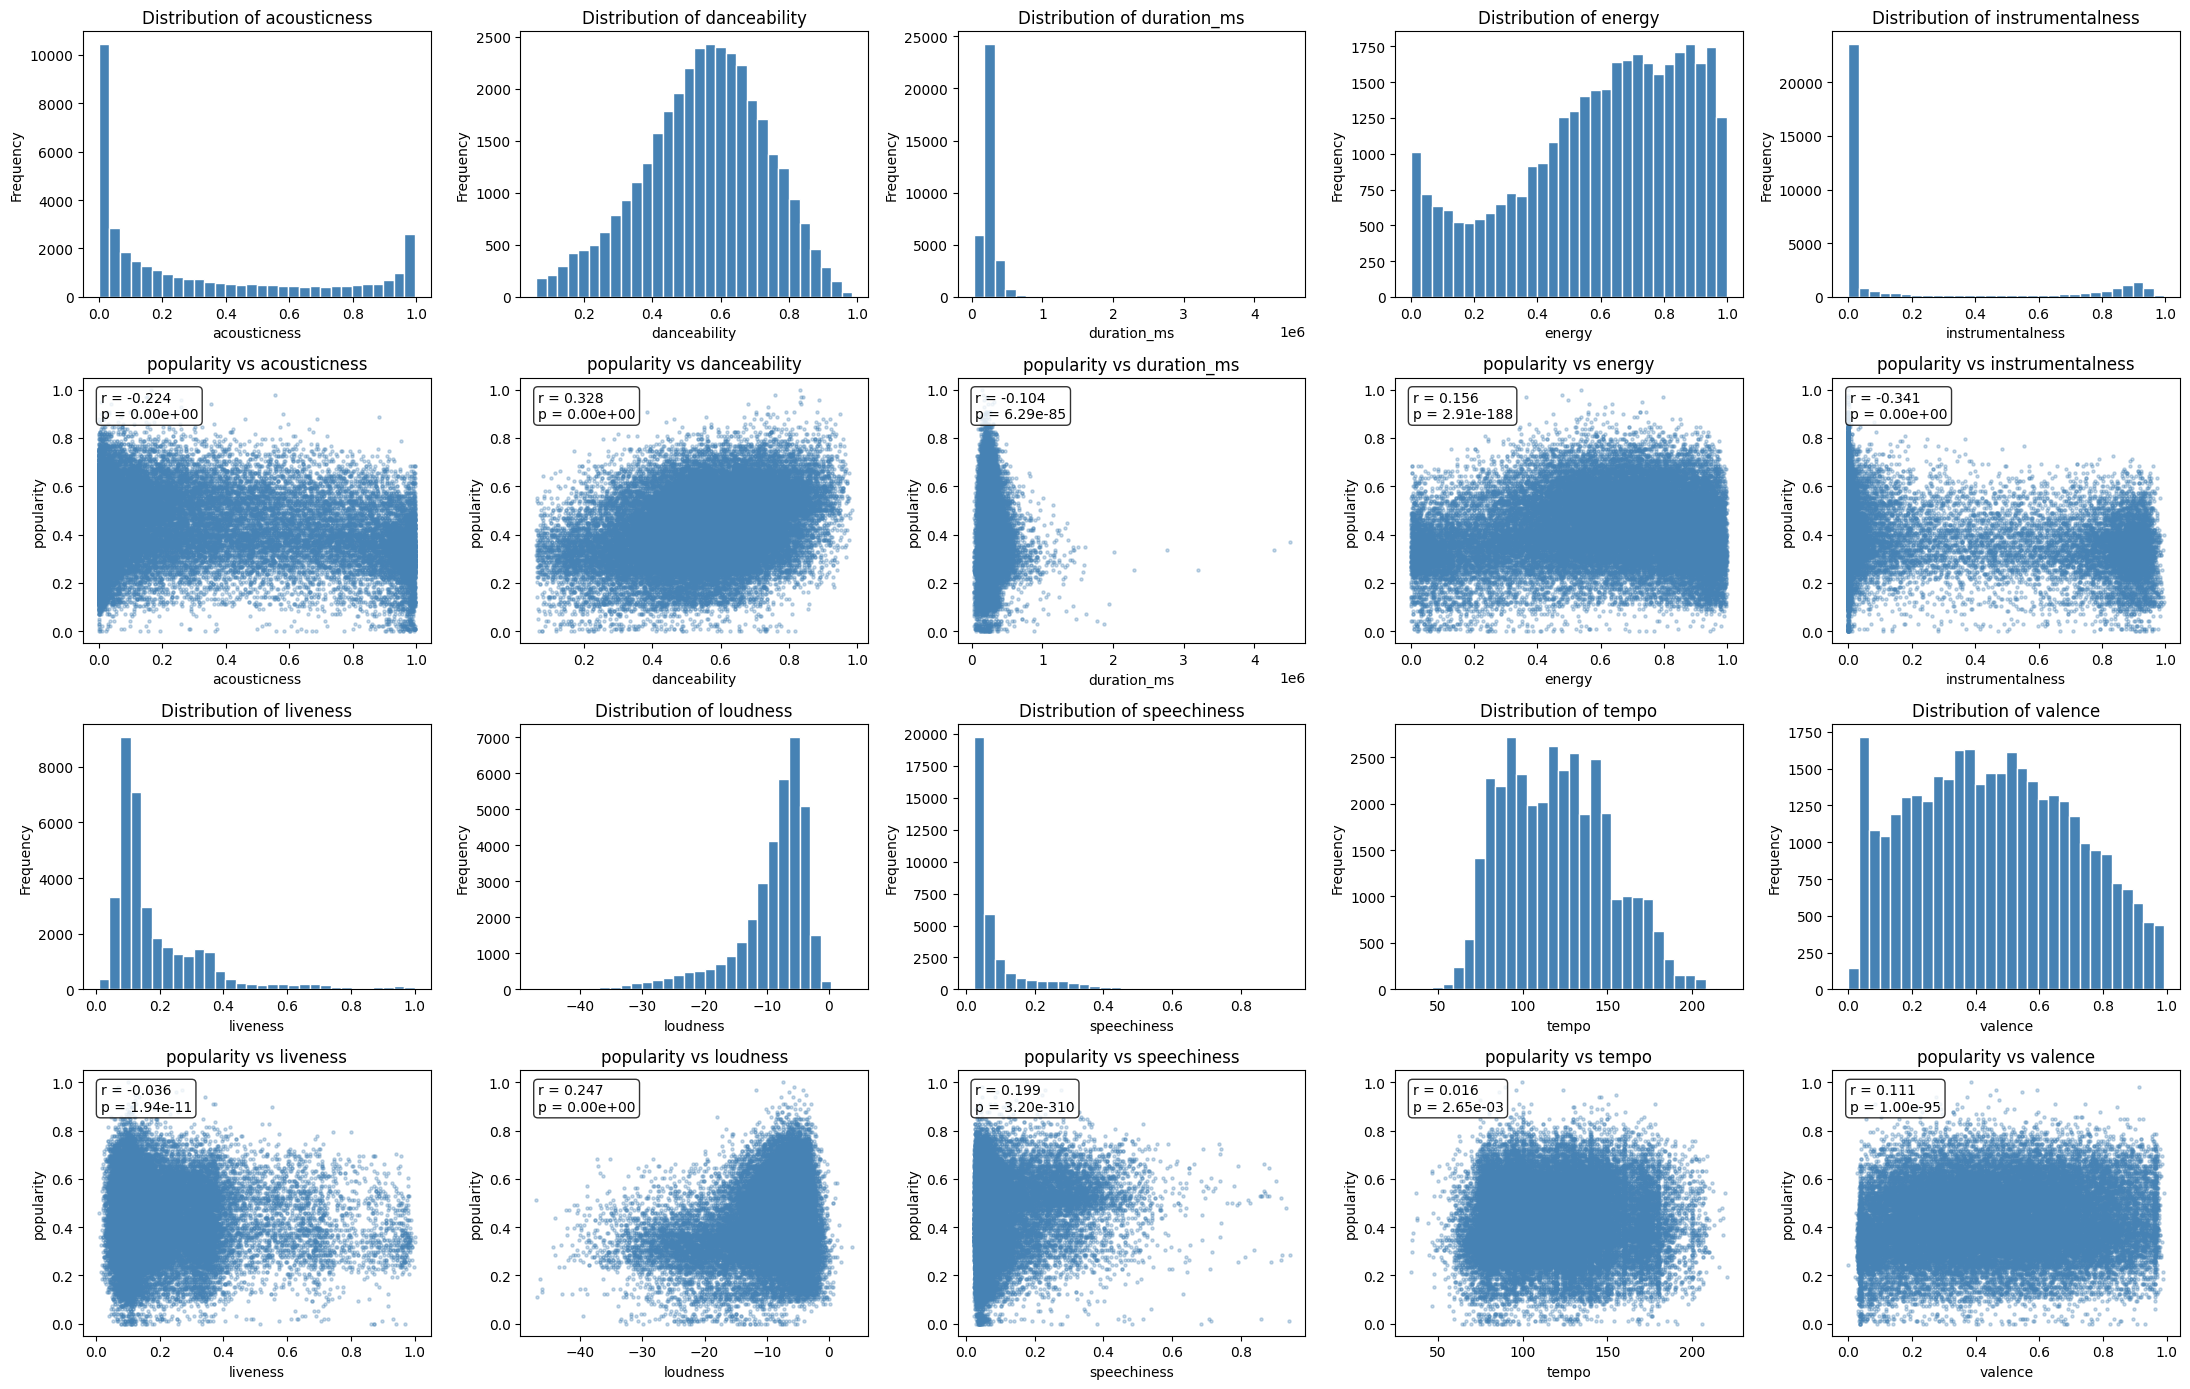

In [97]:
# Check distribution（Continuous Ratio）
# - `acousticness`, `danceability`, `duration_ms`, `energy`, `instrumentalness`
# - `liveness`, `loudness`, `speechiness`, `tempo`, `valence`

from scipy.stats import pearsonr
 
features = ['acousticness','danceability','duration_ms','energy','instrumentalness',
            'liveness','loudness','speechiness','tempo','valence']
 
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
 
for i, col in enumerate(features):
    row_hist = 0 if i < 5 else 2
    row_scat = 1 if i < 5 else 3
    col_idx = i % 5
 
    # histogram
    axes[row_hist, col_idx].hist(df[col].dropna(), bins=30,
                                  color='steelblue', edgecolor='white')
    axes[row_hist, col_idx].set_title(f'Distribution of {col}')
    axes[row_hist, col_idx].set_xlabel(col)
    axes[row_hist, col_idx].set_ylabel('Frequency')
 
    # scatter plot + Pearson r
    valid = df[[col, 'popularity']].dropna()
    r, p = pearsonr(valid[col], valid['popularity'])
 
    axes[row_scat, col_idx].scatter(valid[col], valid['popularity'],
                                     alpha=0.3, s=5, color='steelblue')
    axes[row_scat, col_idx].set_xlabel(col)
    axes[row_scat, col_idx].set_ylabel('popularity')
    axes[row_scat, col_idx].set_title(f'popularity vs {col}')
 
    # display Pearson r and p-value
    axes[row_scat, col_idx].text(
        0.05, 0.95,
        f'r = {r:.3f}\np = {p:.2e}',
        transform=axes[row_scat, col_idx].transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
 
plt.tight_layout()
plt.show()
 

In [98]:
# we can see, in scatter plot, the duration_ms, loudness, speechiness seems single and no linera to the popularity.
# so, lets log it!

# df['duration_ms'] = np.log1p(df['duration_ms'])
# df['loudness'] = np.log1p(df['loudness'])
# df['speechiness'] = np.log1p(df['speechiness'])

# features = ['acousticness','danceability','duration_ms','energy','instrumentalness',
#             'liveness','loudness','speechiness','tempo','valence']
 
# fig, axes = plt.subplots(4, 5, figsize=(22, 14))
 
# for i, col in enumerate(features):
#     row_hist = 0 if i < 5 else 2
#     row_scat = 1 if i < 5 else 3
#     col_idx = i % 5
 
#     # histogram
#     axes[row_hist, col_idx].hist(df[col].dropna(), bins=30,
#                                   color='steelblue', edgecolor='white')
#     axes[row_hist, col_idx].set_title(f'Distribution of {col}')
#     axes[row_hist, col_idx].set_xlabel(col)
#     axes[row_hist, col_idx].set_ylabel('Frequency')
 
#     # scatter plot + Pearson r
#     valid = df[[col, 'popularity']].dropna()
#     r, p = pearsonr(valid[col], valid['popularity'])
 
#     axes[row_scat, col_idx].scatter(valid[col], valid['popularity'],
#                                      alpha=0.3, s=5, color='steelblue')
#     axes[row_scat, col_idx].set_xlabel(col)
#     axes[row_scat, col_idx].set_ylabel('popularity')
#     axes[row_scat, col_idx].set_title(f'popularity vs {col}')
 
#     # display Pearson r and p-value
#     axes[row_scat, col_idx].text(
#         0.05, 0.95,
#         f'r = {r:.3f}\np = {p:.2e}',
#         transform=axes[row_scat, col_idx].transAxes,
#         fontsize=10, verticalalignment='top',
#         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
#     )
 
# plt.tight_layout()
# plt.show()
 
## ok, fine, Pearson correlation worse. So we will not log it, and just use the original one.

In [99]:
df['mode'] = (df['mode'] == 'Major').astype(int)

In [100]:
# **One-hot encoding（Nominal）**
# - `key`, `music_genre`

# **Binary（only keep one column）**
# - `mode`

keys_order = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
df['key'] = pd.Categorical(df['key'], categories=keys_order, ordered=True)
df_encoded = pd.get_dummies(df, columns=['key'], prefix='key', dtype=int)
# avoid dummy variable trap by dropping the first column
df_encoded = df_encoded.drop(columns=['key_C'])

# same to music_genre
genre_order = ['Alternative', 'Anime', 'Blues', 'Classical', 'Country',
               'Electronic', 'Hip-Hop', 'Jazz', 'Rap', 'Rock']
df['music_genre'] = pd.Categorical(df['music_genre'], categories=genre_order)
df_encoded = pd.get_dummies(df_encoded, columns=['music_genre'], prefix='genre', dtype=int)
# avoid dummy variable trap by dropping the first column
df_encoded = df_encoded.drop(columns=['genre_Alternative'])


In [101]:
print(df_encoded.head())

   Unnamed: 0  popularity  acousticness  danceability  duration_ms  energy  \
0           0    0.306122       0.01270         0.622     218293.0   0.890   
1           1    0.275510       0.00306         0.620     215613.0   0.755   
2           2    0.336735       0.02540         0.774     166875.0   0.700   
3           3    0.316327       0.00465         0.638     222369.0   0.587   
4           4    0.459184       0.02890         0.572     214408.0   0.803   

   instrumentalness  liveness  loudness  mode  ...  key_B  genre_Anime  \
0          0.950000     0.124    -7.043     0  ...      0            0   
1          0.011800     0.534    -4.617     1  ...      0            0   
2          0.002530     0.157    -4.498     1  ...      0            0   
3          0.909000     0.157    -6.266     1  ...      0            0   
4          0.000008     0.106    -4.294     1  ...      1            0   

   genre_Blues  genre_Classical  genre_Country  genre_Electronic  \
0            0    

In [102]:
# music_genre
df['music_genre'].value_counts()

music_genre
Anime          4017
Electronic     3857
Jazz           3807
Blues          3776
Country        3713
Classical      3564
Rock           3282
Alternative    3262
Hip-Hop        2877
Rap            2769
Name: count, dtype: int64

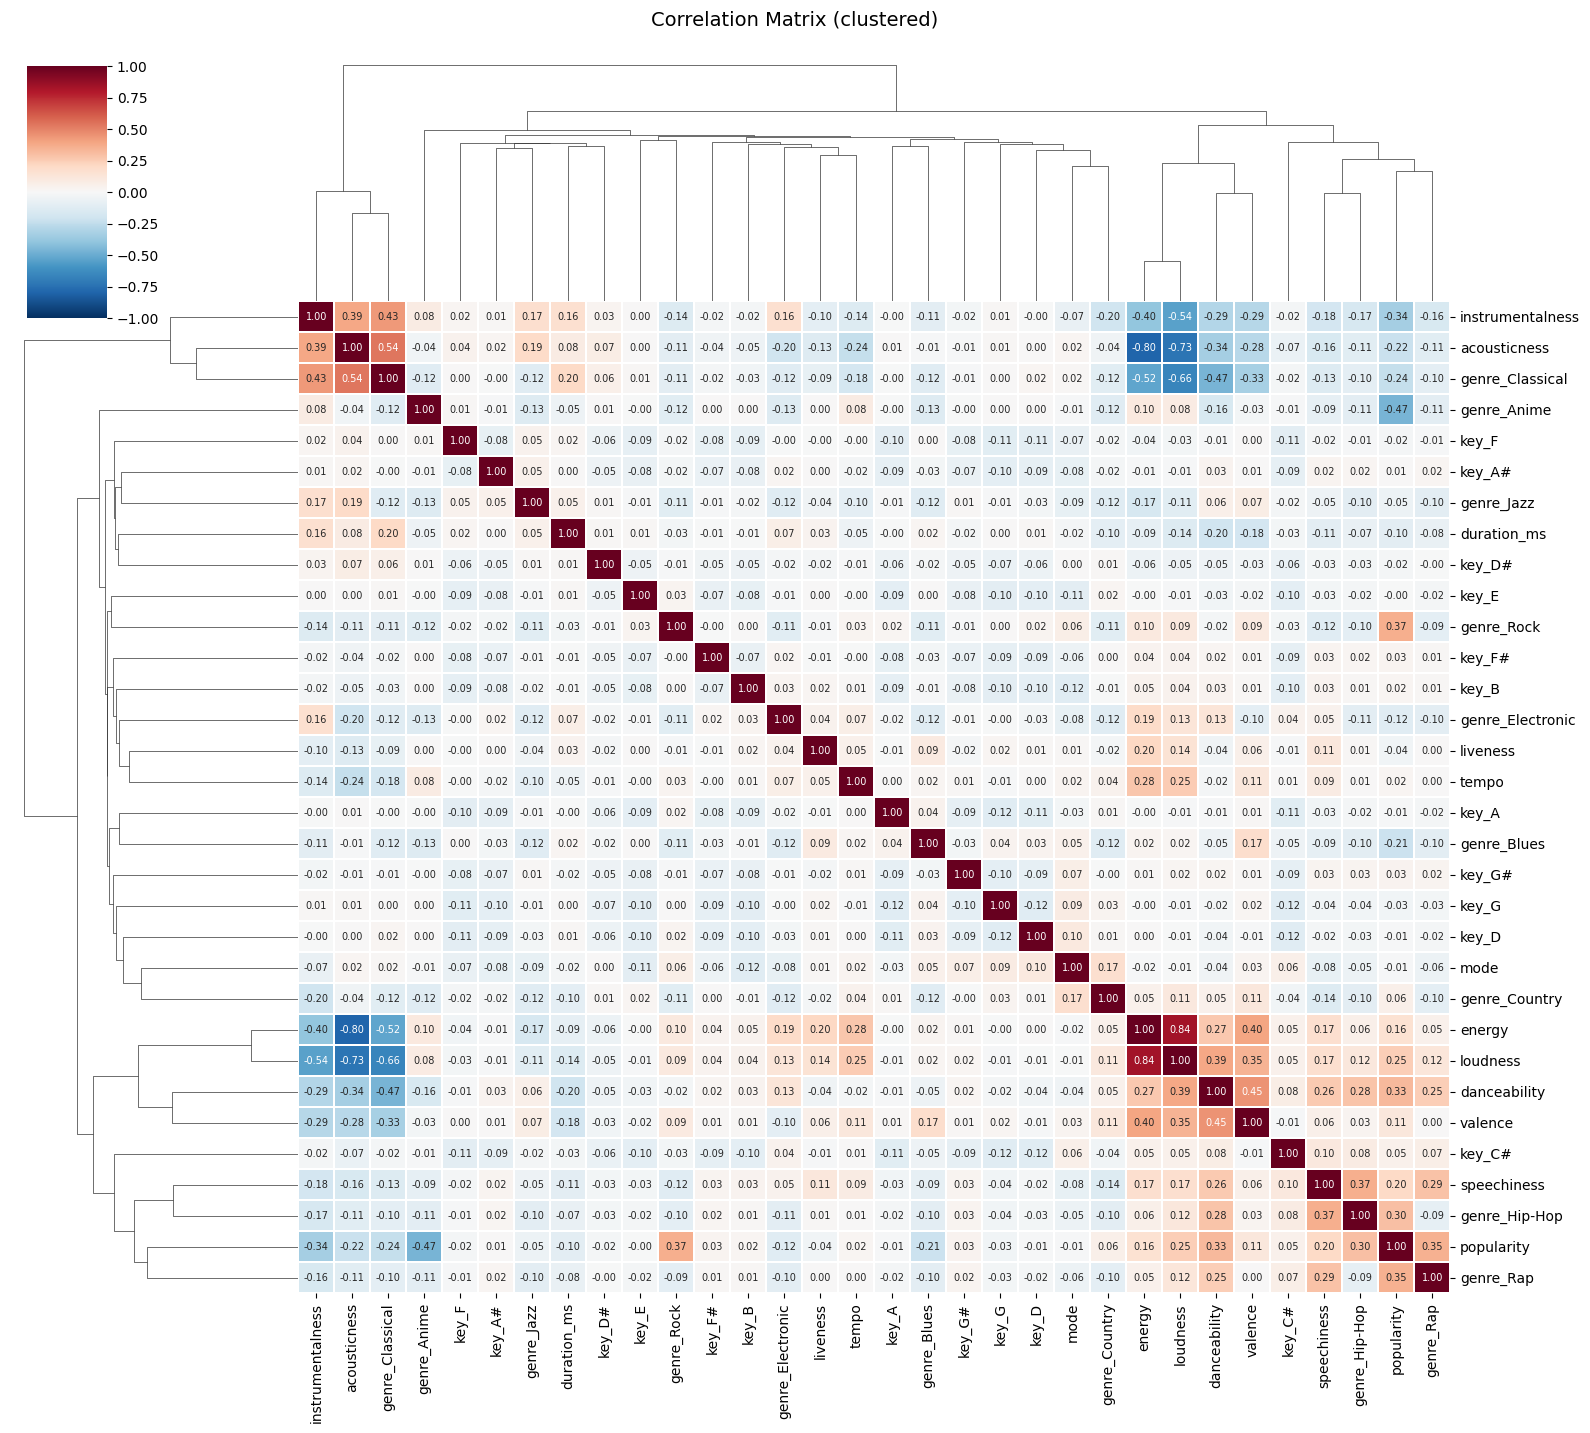

In [103]:
num_df = df_encoded.select_dtypes(include=np.number).drop(
    columns=[c for c in ['Unnamed: 0'] if c in df.columns]
)

corr = num_df.corr()

# 2. plot
g = sns.clustermap(
    corr,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    figsize=(16, 14), linewidths=0.3,
    method='average',           # 聚类方法: average / ward / complete
    metric='euclidean',         # ward 必须配 euclidean
    cbar_kws={'shrink': 0.8}
)
g.fig.suptitle('Correlation Matrix (clustered)', y=1.02, fontsize=14)
plt.show()


In [104]:
# so, lets drop very related features:
# 1. instrumentalness, acousticness, genre_Classical, only keep instrumentalness
# 2. energy, loudness, danceability, valence, only keep energy

df_encoded = df_encoded.drop(columns=['acousticness', 'genre_Classical', 'loudness', 'danceability', 'valence'])

## Linear Regression

In [130]:
df = df_encoded.copy()
random_state = 42

In [122]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [131]:
# 1. Prepare data (do NOT scale y; keep popularity in its original units)
drop_cols = [c for c in ['Unnamed: 0', 'popularity'] if c in df.columns]
X = df.drop(columns=drop_cols)
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)


In [ ]:
# 2. Use a Pipeline so StandardScaler is fit only on the training fold
#    inside each CV iteration (prevents data leakage from validation fold)
def make_pipe(model):
    return Pipeline([('scaler', StandardScaler()), ('model', model)])

cv = KFold(n_splits=5, shuffle=True, random_state=42)





In [141]:
# 3. Baseline: always predict the mean (Zero-R equivalent for regression)
baseline = make_pipe(DummyRegressor(strategy='mean'))
cv_s = cross_val_score(baseline, X_train, y_train, cv=cv)
print(cv_s.mean(), cv_s.std())
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)
print(f'[Baseline (mean)]  R2={r2_score(y_test, pred):.4f}  '
        f'RMSE={np.sqrt(mean_squared_error(y_test, pred)):.4f}  '
        f'MAE={mean_absolute_error(y_test, pred):.4f}')

-6.427675259503828e-05 8.948314152138554e-05
[Baseline (mean)]  R2=-0.0000  RMSE=0.1471  MAE=0.1200


In [142]:
# 4. Plain Linear Regression (no regularization)
lr = make_pipe(LinearRegression())
cv_s = cross_val_score(lr, X_train, y_train, cv=cv)
print(cv_s.mean(), cv_s.std())
# real train
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(f'[LinearRegression]  R2={r2_score(y_test, pred):.4f}  '
      f'RMSE={np.sqrt(mean_squared_error(y_test, pred)):.4f}  '
      f'MAE={mean_absolute_error(y_test, pred):.4f}')

# print the max 10 features
coef = pd.Series(lr.named_steps['model'].coef_, index=X.columns).sort_values(key=abs, ascending=False)
print('\nTop 10 coefficients:')
print(coef.head(10))

0.6103909174941232 0.008299475630087429
[LinearRegression]  R2=0.6022  RMSE=0.0928  MAE=0.0711

Top 10 coefficients:
genre_Anime        -0.060759
genre_Rap           0.047703
genre_Rock          0.046568
genre_Hip-Hop       0.040021
genre_Blues        -0.028864
instrumentalness   -0.019763
energy              0.016512
genre_Electronic   -0.013551
speechiness        -0.007035
liveness           -0.006440
dtype: float64


In [ ]:
# for the genre is most important, what if we remove them?
# remove genre features, and retrain the model to see the difference in performance and coefficients
genre_key_cols = [c for c in X.columns if c.startswith('genre_') or c.startswith('key_')]
audio_cols = [c for c in X.columns if c not in genre_key_cols]


X_reduced = X_train[audio_cols]
lr_reduced = make_pipe(LinearRegression())
cv_s_reduced = cross_val_score(lr_reduced, X_reduced, y_train, cv=cv)
print(cv_s_reduced.mean(), cv_s_reduced.std())
lr_reduced.fit(X_reduced, y_train)
pred_reduced = lr_reduced.predict(X_test[audio_cols])
print(f'[LinearRegression (audio only)]  R2={r2_score(y_test, pred_reduced):.4f}  '
      f'RMSE={np.sqrt(mean_squared_error(y_test, pred_reduced)):.4f}  '
      f'MAE={mean_absolute_error(y_test, pred_reduced):.4f}')   

0.14415911099920484 0.005444179464697863
[LinearRegression (audio only)]  R2=0.1539  RMSE=0.1353  MAE=0.1076


## Logical Regression
lets predict the top 25%

In [144]:
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, average_precision_score)

In [145]:
# 1. Build target: top 25% as positive class
threshold = df['popularity'].quantile(0.75)
y = (df['popularity'] >= threshold).astype(int)
X = df.drop(columns=[c for c in ['Unnamed: 0', 'popularity'] if c in df.columns])
print(f'Threshold: {threshold:.4f}, positive ratio: {y.mean():.4f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state, stratify=y
)

# Stratified CV: keeps the 25/75 ratio in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

Threshold: 0.5408, positive ratio: 0.2536


In [147]:
def report_clf(name, model, X_test=X_test, y_test=y_test):
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    print(f'\n=== {name} ===')
    print(f'ROC-AUC: {roc_auc_score(y_test, prob):.4f}   '
          f'PR-AUC: {average_precision_score(y_test, prob):.4f}')
    print(classification_report(y_test, pred, digits=4))

In [151]:
# baseline

baseline = DummyClassifier(strategy='stratified')
baseline.fit(X_train, y_train)

report_clf('Baseline (stratified)', baseline)



=== Baseline (stratified) ===
ROC-AUC: 0.4961   PR-AUC: 0.2521
              precision    recall  f1-score   support

           0     0.7483    0.7488    0.7485      5214
           1     0.2590    0.2586    0.2588      1771

    accuracy                         0.6245      6985
   macro avg     0.5037    0.5037    0.5037      6985
weighted avg     0.6243    0.6245    0.6244      6985



In [152]:
clf = make_pipe(LogisticRegression(penalty='l1', solver='liblinear',
                                   class_weight='balanced',
                                   max_iter=2000, random_state=random_state))
cv_s = cross_val_score(clf, X_train, y_train, cv=skf, scoring='roc_auc')
print(cv_s.mean(), cv_s.std())
clf.fit(X_train, y_train)
prob = clf.predict_proba(X_test)[:, 1]
pred = clf.predict(X_test)
print(f'[LogisticRegression L1]  ROC_AUC={roc_auc_score(y_test, prob):.4f}  '
      f'PR_AUC={average_precision_score(y_test, prob):.4f}')
print(classification_report(y_test, pred, digits=4))

coef = pd.Series(clf.named_steps['model'].coef_[0], index=X.columns).sort_values(key=abs, ascending=False)
print('\nTop 10 coefficients:')
print(coef.head(10))

0.898142088681487 0.0019463082811371614
[LogisticRegression L1]  ROC_AUC=0.8941  PR_AUC=0.7524
              precision    recall  f1-score   support

           0     0.9167    0.9079    0.9123      5214
           1     0.7364    0.7572    0.7467      1771

    accuracy                         0.8697      6985
   macro avg     0.8266    0.8326    0.8295      6985
weighted avg     0.8710    0.8697    0.8703      6985


Top 10 coefficients:
genre_Anime        -1.268853
genre_Rock          0.839786
genre_Rap           0.793779
genre_Hip-Hop       0.573802
genre_Blues        -0.573550
instrumentalness   -0.441662
genre_Electronic   -0.329118
energy              0.185862
genre_Jazz         -0.166649
duration_ms        -0.156859
dtype: float64


In [153]:
genre_key_cols = [c for c in X.columns if c.startswith('genre_') or c.startswith('key_')]
audio_cols = [c for c in X.columns if c not in genre_key_cols]

X_reduced = X_train[audio_cols]
clf_reduced = make_pipe(LogisticRegression(penalty='l1', solver='liblinear',
                                           class_weight='balanced',
                                           max_iter=2000, random_state=random_state))
cv_s_reduced = cross_val_score(clf_reduced, X_reduced, y_train, cv=skf, scoring='roc_auc')
print(cv_s_reduced.mean(), cv_s_reduced.std())
clf_reduced.fit(X_reduced, y_train)
prob_r = clf_reduced.predict_proba(X_test[audio_cols])[:, 1]
pred_r = clf_reduced.predict(X_test[audio_cols])
print(f'[LogisticRegression L1 (audio only)]  ROC_AUC={roc_auc_score(y_test, prob_r):.4f}  '
      f'PR_AUC={average_precision_score(y_test, prob_r):.4f}')
print(classification_report(y_test, pred_r, digits=4))

0.7079713258874861 0.0021646382624644104
[LogisticRegression L1 (audio only)]  ROC_AUC=0.7022  PR_AUC=0.4029
              precision    recall  f1-score   support

           0     0.8889    0.4544    0.6013      5214
           1     0.3414    0.8329    0.4843      1771

    accuracy                         0.5503      6985
   macro avg     0.6152    0.6436    0.5428      6985
weighted avg     0.7501    0.5503    0.5717      6985



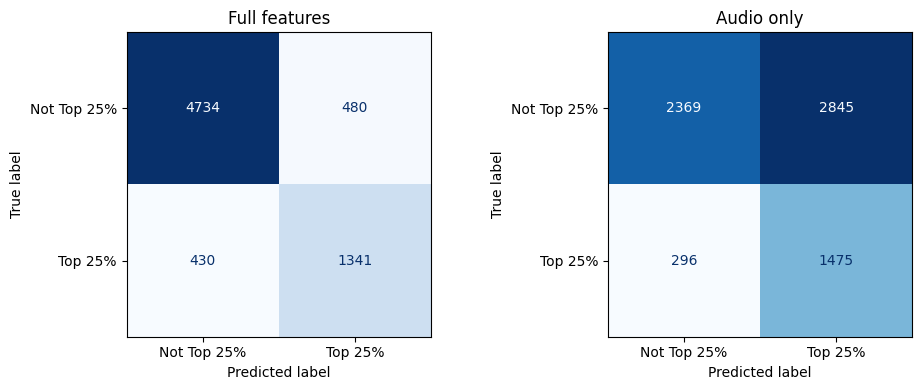

In [154]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, pred, display_labels=['Not Top 25%', 'Top 25%'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Full features')

ConfusionMatrixDisplay.from_predictions(
    y_test, pred_r, display_labels=['Not Top 25%', 'Top 25%'],
    cmap='Blues', ax=axes[1], colorbar=False
)
axes[1].set_title('Audio only')

plt.tight_layout()
plt.show()